# Binary Classification: `basel_bad` Prediction

## 1. Setup & Data Loading

In [45]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    brier_score_loss,
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna
import matplotlib.pyplot as plt

In [46]:
df = pq.read_table('../data/demand_direct.parquet').to_pandas()
print(f'Raw shape: {df.shape}')
print(f"Status distribution:\n{df['status_name'].value_counts()}")

# --- temporal constants ---
# basel_bad needs 12 months on book to mature; 2025-02+ has no observed outcomes
MATURITY_CUTOFF = '2025-01-01'
SPLIT_DATE = '2024-07-01'

# Keep only booked accounts — rejected/canceled have basel_bad=0 by default
# but no actual observed outcome (selection bias)
df = df[df['status_name'] == 'Booked'].copy()
print(f'\nBooked-only shape: {df.shape}')
print(f"\nTarget distribution:\n{df['basel_bad'].value_counts(dropna=False)}")
print(f"\nDate range: {df['mis_Date'].min()} to {df['mis_Date'].max()}")
print(f'Maturity cutoff: {MATURITY_CUTOFF}')
print(f'Train/test split: {SPLIT_DATE}')

Raw shape: (2386685, 42)
Status distribution:
status_name
Rejected    1955508
Canceled     329062
Booked       102115
Name: count, dtype: int64

Booked-only shape: (102115, 42)

Target distribution:
basel_bad
0.0    98291
1.0     2662
NaN     1162
Name: count, dtype: int64

Date range: 2023-01-01 00:00:00 to 2026-02-01 00:00:00
Maturity cutoff: 2025-01-01
Train/test split: 2024-07-01


## 2. Feature Engineering

In [47]:
# --- Tier 1: Strong signal ---

# income decline (ratio < 1 means income dropped)
df['INCOME_RATIO_T2_T1'] = df['INCOME_T2'] / df['INCOME_T1'].replace(0, np.nan)

# absolute income change
df['INCOME_CHANGE'] = df['INCOME_T2'] - df['INCOME_T1']

# missingness of INCOME_T2 is itself a strong predictor (7.7% vs 0.03% default rate)
df['HAS_INCOME_T2'] = df['INCOME_T2'].notna().astype(int)

# total existing products
df['TOTAL_PRODUCTS'] = df['TOTAL_CARD_NBR'] + df['TOTAL_LOAN_NBR']

# --- Tier 2: Moderate signal ---

# debt-to-income ratio
df['INSTALLMENT_TO_INCOME'] = df['INSTALLMENT_AMT'] / df['INCOME_T1'].replace(0, np.nan)

# leverage: how many months of income the loan represents
df['TOTAL_AMT_TO_INCOME'] = df['TOTAL_AMT'] / df['INCOME_T1'].replace(0, np.nan)

# leverage adjusted for joint income
df['TOTAL_INCOME'] = df['INCOME_T1'] + df['INCOME_T2'].fillna(0)
df['TOTAL_AMT_TO_TOTAL_INCOME'] = df['TOTAL_AMT'] / df['TOTAL_INCOME'].replace(0, np.nan)

# monthly payment burden
df['AMT_PER_MONTH'] = df['TOTAL_AMT'] / df['TENOR'].replace(0, np.nan)

# --- Tier 3: Categorical interactions ---

df['PRODTYPE3_X_HOUSE'] = df['product_type_3'] + '_' + df['HOUSE_TYPE']
df['PRODTYPE3_X_CUSTTYPE'] = df['product_type_3'] + '_' + df['CUSTOMER_TYPE']
df['CUSTTYPE_X_HOUSE'] = df['CUSTOMER_TYPE'] + '_' + df['HOUSE_TYPE']

# --- Missing value indicators ---
# Missingness patterns are themselves predictive (INCOME_T2 already covered by HAS_INCOME_T2)
MISS_CANDIDATES = ['MAX_CREDIT_TJ_AV', 'INCIT1_L12', 'HOUSE_YEARS', 'ESTCLI1', 'ESTCLI2']
for col in MISS_CANDIDATES:
    miss_rate = df[col].isna().mean()
    if miss_rate > 0.01:
        flag_name = f'MISS_{col}'
        df[flag_name] = df[col].isna().astype(int)
        print(f'  {flag_name}: {miss_rate:.1%} missing')

print('Engineered features added.')
print(f'DataFrame shape: {df.shape}')

  MISS_MAX_CREDIT_TJ_AV: 7.3% missing
  MISS_ESTCLI1: 6.5% missing
  MISS_ESTCLI2: 6.5% missing
Engineered features added.
DataFrame shape: (102115, 57)


### 2b. Systematic Interaction Search

Brute-force pairwise screening of all feature interactions:
- **Numerical × Numerical**: ratio (A/B) and product (A×B) for every pair
- **Categorical × Categorical**: concatenation (A_B) for every pair

Each candidate is scored by |AUC − 0.5|. An interaction is kept only if it beats
both parent features by at least 1 pp. Uses subsampling (all positives + 200k negatives) for speed.

**Important:** screening uses only training-period data (`mis_Date < SPLIT_DATE`) to avoid target leakage into feature selection.

In [48]:
from itertools import combinations
from sklearn.metrics import roc_auc_score

# --- config ---
MIN_LIFT = 0.01      # minimum AUC lift over best parent (1 pp)
MIN_VALID = 5_000    # minimum valid (non-NaN) observations
SAMPLE_NEG = None    # None = use all negatives (booked-only population is small enough)

# base raw features (exclude already-engineered ones to avoid redundancy)
# SCRPLUST1 excluded from modelling entirely (also in DROP_COLS)
RAW_NUM = ['CODRAMA', 'TOTAL_AMT', 'INSTALLMENT_AMT',
           'TOTAL_CARD_NBR', 'TOTAL_LOAN_NBR', 'BOOK_CARD_NBR', 'BOOK_LOAN_NBR',
           'AGE_T1', 'LEFT_TO_LIVE', 'HOUSE_YEARS', 'TENOR',
           'MAX_CREDIT_TJ_AV', 'INCOME_T1', 'INCOME_T2', 'INCIT1_L12', 'flag_risk3']

RAW_CAT = ['CUSTOMER_TYPE', 'FAMILY_SITUATION', 'HOUSE_TYPE',
           'product_type_2', 'product_type_3', 'CSP', 'CPRO', 'CMAT',
           'ESTCLI1', 'ESTCLI2', 'CSECTOR', 'FLAG_COTIT']

# Use only training-period data to avoid leaking test information into feature selection
df_search = df[df['mis_Date'] < SPLIT_DATE].dropna(subset=['basel_bad']).copy()
df_search['basel_bad'] = df_search['basel_bad'].astype(int)

# subsample: keep ALL positives, sample negatives (or keep all if population is small)
pos = df_search[df_search['basel_bad'] == 1]
neg = df_search[df_search['basel_bad'] == 0]
if SAMPLE_NEG is not None and len(neg) > SAMPLE_NEG:
    neg = neg.sample(n=SAMPLE_NEG, random_state=42)
sample = pd.concat([pos, neg])
y_sample = sample['basel_bad'].values

print(f'Search sample: {len(sample):,} rows ({pos.shape[0]:,} positive, {neg.shape[0]:,} negative)')

# --- precompute individual feature AUCs ---
def safe_auc(y, s):
    """AUC with NaN/inf handling. Returns (auc, n_valid)."""
    valid = np.isfinite(s)
    n = valid.sum()
    if n < MIN_VALID or y[valid].sum() < 10:
        return np.nan, n
    return roc_auc_score(y[valid], s[valid]), n

base_auc = {}
for col in RAW_NUM:
    auc, _ = safe_auc(y_sample, sample[col].values)
    if not np.isnan(auc):
        base_auc[col] = abs(auc - 0.5)

# categorical: target-encode then compute AUC
for col in RAW_CAT:
    te = sample.groupby(col)['basel_bad'].transform('mean').values
    auc, _ = safe_auc(y_sample, te)
    if not np.isnan(auc):
        base_auc[col] = abs(auc - 0.5)

print(f'Base AUCs computed for {len(base_auc)} features')

# --- screen numerical × numerical ---
num_results = []
total_pairs = len(list(combinations(RAW_NUM, 2)))
print(f'\nScreening {total_pairs} numerical pairs (ratio + product)...')

for a, b in combinations(RAW_NUM, 2):
    va = sample[a].values.astype(float)
    vb = sample[b].values.astype(float)
    parent_power = max(base_auc.get(a, 0), base_auc.get(b, 0))

    # ratio A/B
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = va / vb
    auc_r, n_r = safe_auc(y_sample, ratio)
    if not np.isnan(auc_r):
        power = abs(auc_r - 0.5)
        lift = power - parent_power
        if lift >= MIN_LIFT:
            num_results.append({
                'name': f'{a}/{b}', 'type': 'ratio',
                'auc': auc_r, 'power': power, 'lift': lift, 'n_valid': n_r,
                'feat_a': a, 'feat_b': b,
            })

    # product A*B
    product = va * vb
    auc_p, n_p = safe_auc(y_sample, product)
    if not np.isnan(auc_p):
        power = abs(auc_p - 0.5)
        lift = power - parent_power
        if lift >= MIN_LIFT:
            num_results.append({
                'name': f'{a}*{b}', 'type': 'product',
                'auc': auc_p, 'power': power, 'lift': lift, 'n_valid': n_p,
                'feat_a': a, 'feat_b': b,
            })

num_results_df = pd.DataFrame(num_results)
if not num_results_df.empty:
    num_results_df = num_results_df.sort_values('lift', ascending=False)
print(f'Found {len(num_results_df)} numerical interactions with >= {MIN_LIFT:.0%} lift')

# --- screen categorical × categorical ---
cat_results = []
total_cat_pairs = len(list(combinations(RAW_CAT, 2)))
print(f'\nScreening {total_cat_pairs} categorical pairs...')

for a, b in combinations(RAW_CAT, 2):
    combo = sample[a].astype(str) + '_' + sample[b].astype(str)
    te = sample.groupby(combo.values)['basel_bad'].transform('mean').values
    auc_c, n_c = safe_auc(y_sample, te)
    if not np.isnan(auc_c):
        parent_power = max(base_auc.get(a, 0), base_auc.get(b, 0))
        power = abs(auc_c - 0.5)
        lift = power - parent_power
        if lift >= MIN_LIFT:
            cat_results.append({
                'name': f'{a}_x_{b}', 'type': 'cat_concat',
                'auc': auc_c, 'power': power, 'lift': lift, 'n_valid': n_c,
                'feat_a': a, 'feat_b': b,
            })

cat_results_df = pd.DataFrame(cat_results)
if not cat_results_df.empty:
    cat_results_df = cat_results_df.sort_values('lift', ascending=False)
print(f'Found {len(cat_results_df)} categorical interactions with >= {MIN_LIFT:.0%} lift')

print('\nDone.')

Search sample: 50,782 rows (1,935 positive, 48,847 negative)
Base AUCs computed for 28 features

Screening 120 numerical pairs (ratio + product)...
Found 22 numerical interactions with >= 1% lift

Screening 66 categorical pairs...
Found 41 categorical interactions with >= 1% lift

Done.


In [49]:
# --- display results ---
all_results = pd.concat([num_results_df, cat_results_df], ignore_index=True)
if not all_results.empty:
    all_results = all_results.sort_values('lift', ascending=False)
    print(f'=== All interactions with >= {MIN_LIFT:.0%} AUC lift over best parent ===\n')
    display_cols = ['name', 'type', 'auc', 'power', 'lift', 'n_valid']
    print(all_results[display_cols].to_string(index=False, float_format='%.4f'))
else:
    print('No interactions found with sufficient lift.')

=== All interactions with >= 1% AUC lift over best parent ===

                             name       type    auc  power   lift  n_valid
  TOTAL_CARD_NBR/MAX_CREDIT_TJ_AV      ratio 0.6565 0.1565 0.1099    24738
           TENOR/MAX_CREDIT_TJ_AV      ratio 0.6511 0.1511 0.1045    24738
         CODRAMA/MAX_CREDIT_TJ_AV      ratio 0.6459 0.1459 0.0993    22415
          AGE_T1/MAX_CREDIT_TJ_AV      ratio 0.6422 0.1422 0.0773    24738
     HOUSE_YEARS/MAX_CREDIT_TJ_AV      ratio 0.6187 0.1187 0.0721    24737
                       CSP_x_CMAT cat_concat 0.6287 0.1287 0.0644    50772
 INSTALLMENT_AMT/MAX_CREDIT_TJ_AV      ratio 0.6332 0.1332 0.0624    24738
    LEFT_TO_LIVE/MAX_CREDIT_TJ_AV      ratio 0.6264 0.1264 0.0572    24738
       TOTAL_AMT/MAX_CREDIT_TJ_AV      ratio 0.6246 0.1246 0.0547    24738
                       CSP_x_CPRO cat_concat 0.6073 0.1073 0.0430    50772
            product_type_3_x_CMAT cat_concat 0.5972 0.0972 0.0422    50782
                   CMAT_x_ESTCLI2 cat

In [50]:
# --- auto-add discovered interactions to df ---
# skip interactions that duplicate manually-engineered features from section 2a
existing = set(df.columns)
added = []

for _, row in all_results.iterrows():
    col_name = row['name'].replace('/', '_DIV_').replace('*', '_X_')
    if col_name in existing:
        continue

    if row['type'] == 'ratio':
        a, b = row['feat_a'], row['feat_b']
        with np.errstate(divide='ignore', invalid='ignore'):
            df[col_name] = df[a] / df[b].replace(0, np.nan)
        added.append(col_name)
        existing.add(col_name)

    elif row['type'] == 'product':
        a, b = row['feat_a'], row['feat_b']
        df[col_name] = df[a] * df[b]
        added.append(col_name)
        existing.add(col_name)

    elif row['type'] == 'cat_concat':
        a, b = row['feat_a'], row['feat_b']
        df[col_name] = df[a].astype(str) + '_' + df[b].astype(str)
        added.append(col_name)
        existing.add(col_name)

print(f'Auto-added {len(added)} interaction features:')
for name in added:
    print(f'  {name}')
print(f'\nDataFrame shape: {df.shape}')

Auto-added 63 interaction features:
  TOTAL_CARD_NBR_DIV_MAX_CREDIT_TJ_AV
  TENOR_DIV_MAX_CREDIT_TJ_AV
  CODRAMA_DIV_MAX_CREDIT_TJ_AV
  AGE_T1_DIV_MAX_CREDIT_TJ_AV
  HOUSE_YEARS_DIV_MAX_CREDIT_TJ_AV
  CSP_x_CMAT
  INSTALLMENT_AMT_DIV_MAX_CREDIT_TJ_AV
  LEFT_TO_LIVE_DIV_MAX_CREDIT_TJ_AV
  TOTAL_AMT_DIV_MAX_CREDIT_TJ_AV
  CSP_x_CPRO
  product_type_3_x_CMAT
  CMAT_x_ESTCLI2
  CMAT_x_ESTCLI1
  FAMILY_SITUATION_x_CSP
  FAMILY_SITUATION_x_CMAT
  product_type_3_x_CPRO
  CPRO_x_ESTCLI2
  CPRO_x_ESTCLI1
  HOUSE_TYPE_x_CSP
  CSP_x_ESTCLI2
  product_type_3_x_ESTCLI2
  CSP_x_ESTCLI1
  HOUSE_TYPE_x_CMAT
  product_type_3_x_ESTCLI1
  FAMILY_SITUATION_x_HOUSE_TYPE
  product_type_3_x_CSP
  FAMILY_SITUATION_x_ESTCLI2
  FAMILY_SITUATION_x_ESTCLI1
  FAMILY_SITUATION_x_CPRO
  CODRAMA_X_INCOME_T2
  HOUSE_TYPE_x_ESTCLI2
  INSTALLMENT_AMT_X_AGE_T1
  HOUSE_TYPE_x_ESTCLI1
  HOUSE_TYPE_x_CPRO
  CPRO_x_CMAT
  HOUSE_TYPE_x_product_type_3
  product_type_3_x_FLAG_COTIT
  FAMILY_SITUATION_x_product_type_3
  product_t

In [51]:
df.head()

,CUSTOMER_TYPE,FAMILY_SITUATION,HOUSE_TYPE,rf_business_name,rf_ext_business_name,a_business_name,ext_business_name,reject_reason,mis_Date,status_name,...,product_type_2_x_FLAG_COTIT,TOTAL_AMT_X_INCOME_T1,CUSTOMER_TYPE_x_CSECTOR,CUSTOMER_TYPE_x_CMAT,AGE_T1_X_INCOME_T1,TOTAL_AMT_DIV_TENOR,TOTAL_LOAN_NBR_X_INCOME_T2,HOUSE_TYPE_x_FLAG_COTIT,TOTAL_CARD_NBR_DIV_TOTAL_LOAN_NBR,TENOR_X_INCOME_T2
2284545,KNOWN,divorced,Owner,A-Score DIRECT 2024,Equifax Risk Score V3 - Direct CTLM,A-Score DIRECT 2024,Equifax Risk Score - Direct CTLM,NaN,2024-05-01,Booked,...,Consolidation_N,200489250.0,KNOWN_BAN,KNOWN_501,344430.25,406.250000,NaN,Owner_N,0.0,NaN
2284546,KNOWN,married,Rent,A-Score DIRECT 2024,Equifax Risk Score V3 - Direct CTLM,A-Score DIRECT,Equifax Risk Score - Direct CTLM,NaN,2024-04-01,Booked,...,Known_N,3372600.0,KNOWN_BAN,KNOWN_481,152891.20,31.250000,NaN,Rent_N,0.0,NaN
2284547,KNOWN,married,Owner,A-Score DIRECT 2024,Equifax Risk Score V3 - Direct CTLM,A-Score DIRECT,Equifax Risk Score - Direct CTLM,NaN,2023-03-01,Booked,...,Known_N,32818172.1,KNOWN_BAN,KNOWN_900,77906.64,327.638889,NaN,Owner_N,NaN,NaN
2284548,KNOWN,married,Owner,A-Score DIRECT 2024,Equifax Risk Score V3 - Direct CTLM,A-Score DIRECT,Equifax Risk Score - Direct CTLM,NaN,2024-03-01,Booked,...,Known_N,28311300.0,KNOWN_DIV,KNOWN_501,264238.80,100.000000,NaN,Owner_N,NaN,NaN
2284549,KNOWN,concubine,Owner,A-Score DIRECT 2024,Equifax Risk Score V3 - Direct CTLM,A-Score DIRECT 2024,Equifax Risk Score - Direct CTLM,NaN,2024-06-01,Booked,...,Known_N,72030000.0,KNOWN_DIV,KNOWN_900,160867.00,326.086957,NaN,Owner_N,1.0,NaN


## 3. Feature Selection

In [52]:
TARGET = 'basel_bad'

# columns to exclude: identifiers, metadata, date (used for split), benchmark scores (evaluated separately)
DROP_COLS = [
    TARGET,
    'authorization_id',
    'mis_Date',
    'rf_business_name',
    'rf_ext_business_name',
    'a_business_name',
    'ext_business_name',
    'SCRPLUST1',  
    'reject_reason',
    'status_name',        # constant after booked-only filter
    'risk_score_rf',      # benchmark — excluded from model features
    'score_RF',           # benchmark — excluded from model features
]

feature_cols = [c for c in df.columns if c not in DROP_COLS]

cat_cols = [c for c in feature_cols if df[c].dtype == 'object' or df[c].dtype.name == 'str']
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f'Categorical features ({len(cat_cols)}): {cat_cols}')
print(f'Numerical features ({len(num_cols)}): {num_cols}')

Categorical features (57): ['CUSTOMER_TYPE', 'FAMILY_SITUATION', 'HOUSE_TYPE', 'product_type_1', 'product_type_2', 'product_type_3', 'CSP', 'CPRO', 'CMAT', 'ESTCLI1', 'ESTCLI2', 'CSECTOR', 'FLAG_COTIT', 'PRODTYPE3_X_HOUSE', 'PRODTYPE3_X_CUSTTYPE', 'CUSTTYPE_X_HOUSE', 'CSP_x_CMAT', 'CSP_x_CPRO', 'product_type_3_x_CMAT', 'CMAT_x_ESTCLI2', 'CMAT_x_ESTCLI1', 'FAMILY_SITUATION_x_CSP', 'FAMILY_SITUATION_x_CMAT', 'product_type_3_x_CPRO', 'CPRO_x_ESTCLI2', 'CPRO_x_ESTCLI1', 'HOUSE_TYPE_x_CSP', 'CSP_x_ESTCLI2', 'product_type_3_x_ESTCLI2', 'CSP_x_ESTCLI1', 'HOUSE_TYPE_x_CMAT', 'product_type_3_x_ESTCLI1', 'FAMILY_SITUATION_x_HOUSE_TYPE', 'product_type_3_x_CSP', 'FAMILY_SITUATION_x_ESTCLI2', 'FAMILY_SITUATION_x_ESTCLI1', 'FAMILY_SITUATION_x_CPRO', 'HOUSE_TYPE_x_ESTCLI2', 'HOUSE_TYPE_x_ESTCLI1', 'HOUSE_TYPE_x_CPRO', 'CPRO_x_CMAT', 'HOUSE_TYPE_x_product_type_3', 'product_type_3_x_FLAG_COTIT', 'FAMILY_SITUATION_x_product_type_3', 'product_type_3_x_CSECTOR', 'product_type_2_x_CMAT', 'CSP_x_FLAG_COTIT'

## 4. Temporal Train / Test Split

`basel_bad` has zero positives from 2025-02 onward (outcome window not yet matured).  
Only data up to 2025-01 is usable. We split by `mis_Date`:
- **Train**: 2023-01 to 2024-06
- **Test**: 2024-07 to 2025-01

In [53]:
# keep only rows with matured outcomes
df_model = df[df['mis_Date'] <= MATURITY_CUTOFF].dropna(subset=[TARGET]).copy()
df_model[TARGET] = df_model[TARGET].astype(int)

train_mask = df_model['mis_Date'] < SPLIT_DATE
test_mask = df_model['mis_Date'] >= SPLIT_DATE

X_train = df_model.loc[train_mask, feature_cols]
y_train = df_model.loc[train_mask, TARGET]
X_test = df_model.loc[test_mask, feature_cols]
y_test = df_model.loc[test_mask, TARGET]

# keep benchmark scores for test set
bench_risk_score_rf = df_model.loc[test_mask, 'risk_score_rf']
bench_score_RF = df_model.loc[test_mask, 'score_RF']

print(f'Train: {X_train.shape}  ({y_train.mean():.4f} target rate)')
print(f'Test:  {X_test.shape}  ({y_test.mean():.4f} target rate)')
print(f'\nTrain period: {df_model.loc[train_mask, "mis_Date"].min()} to {df_model.loc[train_mask, "mis_Date"].max()}')
print(f'Test period:  {df_model.loc[test_mask, "mis_Date"].min()} to {df_model.loc[test_mask, "mis_Date"].max()}')

Train: (50782, 108)  (0.0381 target rate)
Test:  (16109, 108)  (0.0379 target rate)

Train period: 2023-01-01 00:00:00 to 2024-06-01 00:00:00
Test period:  2024-07-01 00:00:00 to 2025-01-01 00:00:00


### 4b. Cardinality Reduction

Interaction features can produce very high cardinality (e.g. CSP × CMAT ≈ 800 levels).
For each categorical, keep only the top-N most frequent categories (based on training data) and group the rest as `Other`.

In [54]:
MAX_CATEGORIES = 20  # keep top-N categories per feature, group the rest

X_train = X_train.copy()
X_test = X_test.copy()

cardinality_maps = {}  # store for reproducibility
for col in cat_cols:
    top_cats = X_train[col].value_counts().nlargest(MAX_CATEGORIES).index
    cardinality_maps[col] = set(top_cats)
    n_before = X_train[col].nunique()
    X_train[col] = X_train[col].where(X_train[col].isin(top_cats), 'Other')
    X_test[col] = X_test[col].where(X_test[col].isin(top_cats), 'Other')
    n_after = X_train[col].nunique()
    if n_before != n_after:
        print(f'  {col}: {n_before} -> {n_after} categories')

print(f'\nCardinality reduction complete (max {MAX_CATEGORIES} per feature).')

  CSP: 25 -> 21 categories
  CMAT: 31 -> 21 categories
  ESTCLI1: 7 -> 8 categories
  ESTCLI2: 8 -> 9 categories
  PRODTYPE3_X_HOUSE: 31 -> 21 categories
  CSP_x_CMAT: 471 -> 21 categories
  CSP_x_CPRO: 207 -> 21 categories
  product_type_3_x_CMAT: 159 -> 21 categories
  CMAT_x_ESTCLI2: 137 -> 21 categories
  CMAT_x_ESTCLI1: 134 -> 21 categories
  FAMILY_SITUATION_x_CSP: 127 -> 21 categories
  FAMILY_SITUATION_x_CMAT: 148 -> 21 categories
  product_type_3_x_CPRO: 48 -> 21 categories
  CPRO_x_ESTCLI2: 57 -> 21 categories
  CPRO_x_ESTCLI1: 57 -> 21 categories
  HOUSE_TYPE_x_CSP: 106 -> 21 categories
  CSP_x_ESTCLI2: 118 -> 21 categories
  product_type_3_x_ESTCLI2: 37 -> 21 categories
  CSP_x_ESTCLI1: 119 -> 21 categories
  HOUSE_TYPE_x_CMAT: 112 -> 21 categories
  product_type_3_x_ESTCLI1: 36 -> 21 categories
  FAMILY_SITUATION_x_HOUSE_TYPE: 29 -> 21 categories
  product_type_3_x_CSP: 129 -> 21 categories
  FAMILY_SITUATION_x_ESTCLI2: 32 -> 21 categories
  FAMILY_SITUATION_x_ESTCLI1: 32 

## 5. Preprocessing

In [55]:
# --- Main preprocessor (for LR, XGBoost, stacking) ---
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', TargetEncoder(smooth='auto', cv=5, random_state=42)),
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols),
])

# --- LightGBM-specific preprocessor (native categorical handling) ---
# LightGBM finds optimal categorical splits natively, outperforming target encoding.
lgbm_num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

lgbm_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

lgbm_preprocessor = ColumnTransformer([
    ('num', lgbm_num_transformer, num_cols),
    ('cat', lgbm_cat_transformer, cat_cols),
])

# Categorical feature indices for LightGBM (numericals come first)
lgbm_cat_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

### 5b. Recursive Feature Elimination

Use RFECV with a lightweight LightGBM to find the optimal feature subset.
Eliminates features one at a time, scoring each subset via cross-validated Average Precision.

Fitting estimator with 108 features.
Fitting estimator with 108 features.
Fitting estimator with 108 features.
Fitting estimator with 108 features.
Fitting estimator with 108 features.
Fitting estimator with 107 features.
Fitting estimator with 107 features.
Fitting estimator with 107 features.
Fitting estimator with 107 features.
Fitting estimator with 107 features.
Fitting estimator with 106 features.
Fitting estimator with 106 features.
Fitting estimator with 106 features.
Fitting estimator with 106 features.
Fitting estimator with 106 features.
Fitting estimator with 105 features.
Fitting estimator with 105 features.
Fitting estimator with 105 features.
Fitting estimator with 105 features.
Fitting estimator with 105 features.
Fitting estimator with 104 features.
Fitting estimator with 104 features.
Fitting estimator with 104 features.
Fitting estimator with 104 features.
Fitting estimator with 104 features.
Fitting estimator with 103 features.
Fitting estimator with 103 features.
F

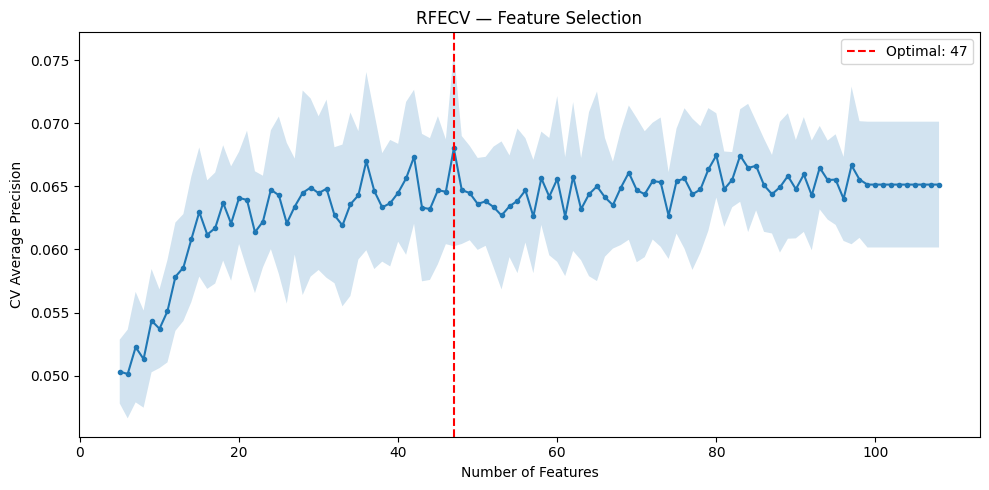


After RFE — Numerical: 23, Categorical: 24, Total: 47
X_train: (50782, 47), X_test: (16109, 47)


In [56]:
from sklearn.feature_selection import RFECV
import warnings

# Lightweight LightGBM for feature ranking
rfe_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
rfe_estimator = LGBMClassifier(
    n_estimators=100,
    num_leaves=31,
    scale_pos_weight=rfe_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

# Preprocess training data for RFE (pass y for TargetEncoder)
all_feature_names = num_cols + cat_cols
X_train_rfe = preprocessor.fit_transform(X_train, y=y_train)

# RFECV subsets columns by index internally, stripping DataFrame column names.
# This triggers a harmless LightGBM warning — suppress it during RFE only.
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='X does not have valid feature names')
    rfecv = RFECV(
        estimator=rfe_estimator,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='average_precision',
        min_features_to_select=5,
        n_jobs=-1,
        verbose=1,
    )
    rfecv.fit(X_train_rfe, y_train)

# Results
selected_mask = rfecv.support_
selected_set = {f for f, s in zip(all_feature_names, selected_mask) if s}
eliminated = [f for f, s in zip(all_feature_names, selected_mask) if not s]

print(f'\nOptimal features: {rfecv.n_features_} / {len(all_feature_names)}')
print(f'\nEliminated ({len(eliminated)}): {eliminated}')

# Plot CV score vs number of features
fig, ax = plt.subplots(figsize=(10, 5))
n_feats = rfecv.cv_results_['n_features']
mean_scores = rfecv.cv_results_['mean_test_score']
std_scores = rfecv.cv_results_['std_test_score']
ax.plot(n_feats, mean_scores, marker='o', markersize=3)
ax.fill_between(n_feats, mean_scores - std_scores, mean_scores + std_scores, alpha=0.2)
ax.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_}')
ax.set_xlabel('Number of Features')
ax.set_ylabel('CV Average Precision')
ax.set_title('RFECV — Feature Selection')
ax.legend()
plt.tight_layout()
plt.show()

# Update feature lists and rebuild both preprocessors with selected features only
num_cols = [c for c in num_cols if c in selected_set]
cat_cols = [c for c in cat_cols if c in selected_set]
feature_cols = [c for c in feature_cols if c in selected_set]

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols),
])

lgbm_preprocessor = ColumnTransformer([
    ('num', lgbm_num_transformer, num_cols),
    ('cat', lgbm_cat_transformer, cat_cols),
])
lgbm_cat_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

print(f'\nAfter RFE — Numerical: {len(num_cols)}, Categorical: {len(cat_cols)}, Total: {len(feature_cols)}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

## 6. Model Definitions & Hyperparameter Tuning

In [57]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class imbalance ratio: {pos_weight:.0f}:1')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Class imbalance ratio: 25:1


### 6a. Logistic Regression

In [58]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=42,
        solver='saga',
    )),
])

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__l1_ratio': [0.0, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_search = GridSearchCV(
    lr_pipe, lr_param_grid,
    scoring='average_precision',
    cv=cv, n_jobs=-1, verbose=1,
)
lr_search.fit(X_train, y_train)

print(f'Best params: {lr_search.best_params_}')
print(f'Best CV PR AUC: {lr_search.best_score_:.4f}')

lr_model = lr_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best params: {'classifier__C': 10.0, 'classifier__l1_ratio': 1.0}
Best CV PR AUC: 0.0663


/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 6b. LightGBM (Optuna + native categorical handling)

In [60]:
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 80),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    pipe = Pipeline([
        ('preprocessor', lgbm_preprocessor),
        ('classifier', LGBMClassifier(
            scale_pos_weight=pos_weight,
            max_depth=-1,
            random_state=42,
            n_jobs=1,
            verbosity=-1,
            **params,
        )),
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1,
        params={'classifier__categorical_feature': lgbm_cat_indices},
    )
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
lgbm_study = optuna.create_study(direction='maximize', study_name='lgbm')
lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f'Best trial: {lgbm_study.best_trial.number}')
print(f'Best CV PR AUC: {lgbm_study.best_value:.4f}')
print(f'Best params: {lgbm_study.best_params}')

# Refit best model on full training data
lgbm_model = Pipeline([
    ('preprocessor', lgbm_preprocessor),
    ('classifier', LGBMClassifier(
        scale_pos_weight=pos_weight,
        max_depth=-1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **lgbm_study.best_params,
    )),
])
lgbm_model.fit(X_train, y_train, classifier__categorical_feature=lgbm_cat_indices)

  0%|          | 0/50 [00:00<?, ?it/s]

/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier wa

Best trial: 47
Best CV PR AUC: 0.0702
Best params: {'n_estimators': 221, 'learning_rate': 0.006713017927540624, 'num_leaves': 16, 'min_child_samples': 117, 'subsample': 0.9198765091481574, 'colsample_bytree': 0.7406654351650064, 'reg_alpha': 2.2682645074560786e-06, 'reg_lambda': 0.8755174734433558}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### 6c. XGBoost (Optuna)

In [61]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            scale_pos_weight=pos_weight,
            random_state=42,
            n_jobs=1,
            verbosity=0,
            eval_metric='aucpr',
            **params,
        )),
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1,
    )
    return scores.mean()

xgb_study = optuna.create_study(direction='maximize', study_name='xgb')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f'Best trial: {xgb_study.best_trial.number}')
print(f'Best CV PR AUC: {xgb_study.best_value:.4f}')
print(f'Best params: {xgb_study.best_params}')

# Refit best model on full training data
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        eval_metric='aucpr',
        **xgb_study.best_params,
    )),
])
xgb_model.fit(X_train, y_train)

  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 36
Best CV PR AUC: 0.0713
Best params: {'n_estimators': 665, 'learning_rate': 0.005910796608273469, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.6835618557809651, 'colsample_bytree': 0.7241456330152705, 'gamma': 1.870989835044081e-06, 'reg_alpha': 0.0018302980847566892, 'reg_lambda': 0.03322246902164654}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### 6d. Stacking Ensemble

Blend all 3 base models via a meta-learner (LogisticRegression) trained on
cross-validated out-of-fold predictions. All base models use TargetEncoder
preprocessing for compatibility with StackingClassifier.

In [62]:
stack_estimators = [
    ('lr', Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced', max_iter=5000, random_state=42, solver='saga',
            C=lr_search.best_params_['classifier__C'],
            l1_ratio=lr_search.best_params_['classifier__l1_ratio'],
        )),
    ])),
    ('lgbm', Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(
            scale_pos_weight=pos_weight, max_depth=-1,
            random_state=42, n_jobs=1, verbosity=-1,
            **lgbm_study.best_params,
        )),
    ])),
    ('xgb', Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            scale_pos_weight=pos_weight,
            random_state=42, n_jobs=1, verbosity=0, eval_metric='aucpr',
            **xgb_study.best_params,
        )),
    ])),
]

stack_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=cv,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False,
)

stack_model.fit(X_train, y_train)
print('Stacking ensemble fitted.')

stack_cv_scores = cross_val_score(
    stack_model, X_train, y_train,
    cv=cv, scoring='average_precision', n_jobs=-1,
)
print(f'Stacking CV PR AUC: {stack_cv_scores.mean():.4f} (+/- {stack_cv_scores.std():.4f})')

/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking ensemble fitted.


/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

Stacking CV PR AUC: 0.0696 (+/- 0.0018)


## 7. Evaluation — All Models + Benchmarks

In [63]:
def evaluate(name, y_true, y_score, is_probability=True):
    """Compute metrics for a single model/benchmark."""
    mask = ~np.isnan(y_score)
    y_true, y_score = y_true[mask], y_score[mask]
    result = {
        'Model': name,
        'ROC AUC': roc_auc_score(y_true, y_score),
        'PR AUC': average_precision_score(y_true, y_score),
        'N': mask.sum(),
    }
    # Brier score only meaningful for calibrated probabilities
    result['Brier'] = brier_score_loss(y_true, np.clip(y_score, 0, 1)) if is_probability else np.nan
    return result

# model predictions
results = []
model_preds = {}  # store for plotting

for name, mdl in [('Logistic Regression', lr_model), ('LightGBM', lgbm_model),
                   ('XGBoost', xgb_model), ('Stacking', stack_model)]:
    y_proba = mdl.predict_proba(X_test)[:, 1]
    model_preds[name] = y_proba
    results.append(evaluate(name, y_test.values, y_proba))

# benchmark scores: higher = safer, so negate for ranking (higher = riskier)
for name, scores in [('risk_score_rf (benchmark)', bench_risk_score_rf), ('score_RF (benchmark)', bench_score_RF)]:
    negated = -scores.values
    model_preds[name] = negated
    results.append(evaluate(name, y_test.values, negated, is_probability=False))

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('PR AUC', ascending=False)
print(results_df.to_string(float_format='%.4f'))

/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/inigo_ocariz/src/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                           ROC AUC  PR AUC      N  Brier
Model                                                   
risk_score_rf (benchmark)   0.6613  0.0879  16105    NaN
Stacking                    0.6628  0.0669  16109 0.0361
XGBoost                     0.6612  0.0658  16109 0.1948
LightGBM                    0.6555  0.0655  16109 0.1262
Logistic Regression         0.6550  0.0652  16109 0.2279
score_RF (benchmark)        0.6185  0.0538  16108    NaN


## 8. ROC & Precision-Recall Curves

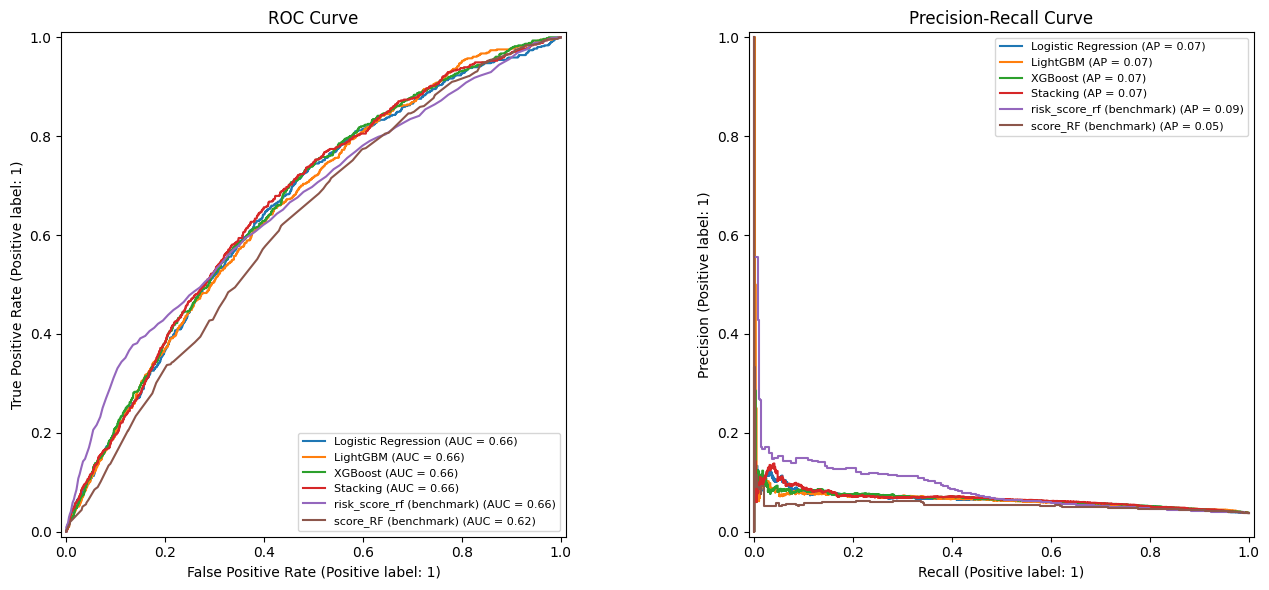

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, scores in model_preds.items():
    mask = ~np.isnan(scores)
    RocCurveDisplay.from_predictions(y_test.values[mask], scores[mask], ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(y_test.values[mask], scores[mask], ax=axes[1], name=name)

axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right', fontsize=8)
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Feature Importance (Best Tree Model)

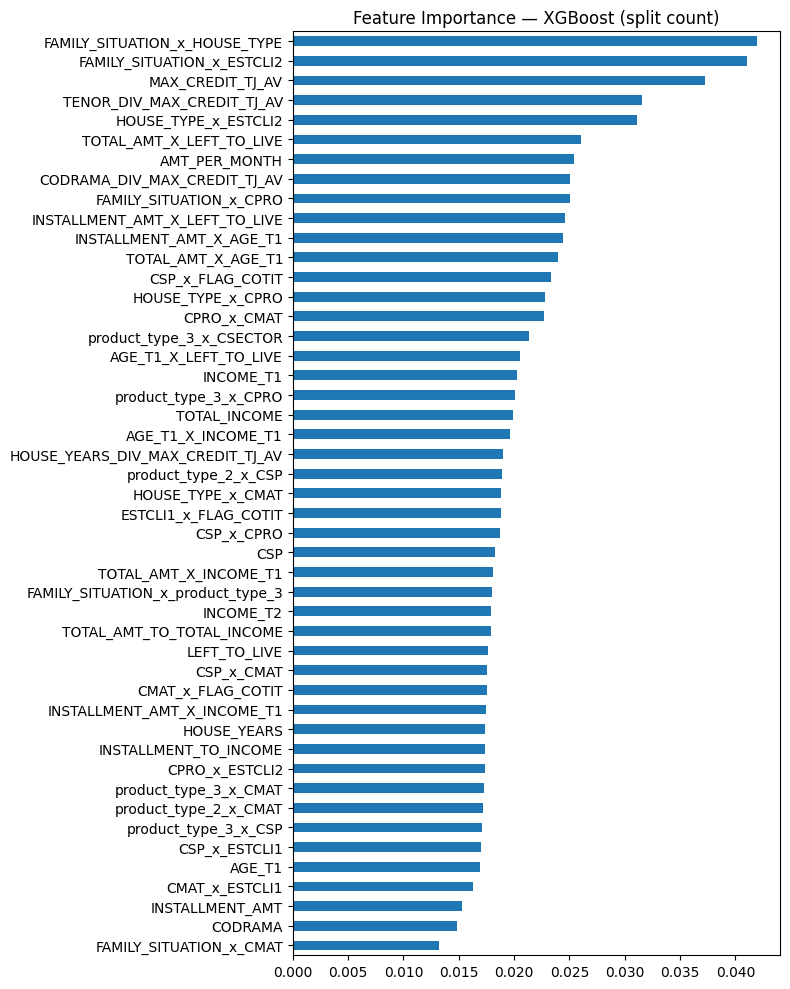

In [65]:
# pick best tree model by PR AUC
tree_results = {k: v for k, v in zip(['LightGBM', 'XGBoost'], [lgbm_model, xgb_model])}
best_tree_name = results_df.loc[results_df.index.isin(tree_results.keys()), 'PR AUC'].idxmax()
best_tree = tree_results[best_tree_name]

clf = best_tree.named_steps['classifier']
feature_names = num_cols + cat_cols
importance = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
importance.plot.barh(ax=ax)
ax.set_title(f'Feature Importance — {best_tree_name} (split count)')
plt.tight_layout()
plt.show()

## 10. Logistic Regression Coefficients

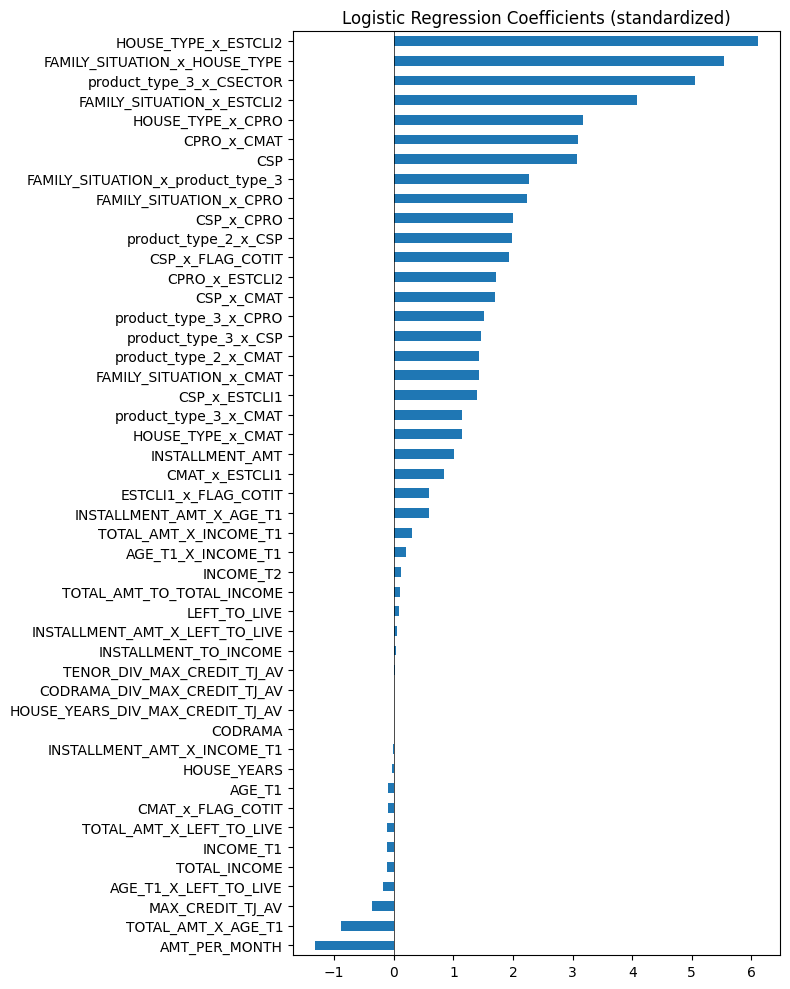

In [66]:
lr_clf = lr_model.named_steps['classifier']
coefs = pd.Series(lr_clf.coef_[0], index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
coefs.plot.barh(ax=ax)
ax.set_title('Logistic Regression Coefficients (standardized)')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()